# SMS Spam Classification using SVM
Dataset: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset?resource=download

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Install (if needed)
!pip -q install wordcloud nltk scikit-learn


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
import re, string, nltk
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_curve, auc, RocCurveDisplay # Added RocCurveDisplay here
)

nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Upload dataset (`spam.csv`) downloaded from Kaggle.

In [12]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam (2).csv


In [13]:
df = pd.read_csv("spam.csv", encoding="latin-1")

df = df[['v1', 'v2']]

df.columns = ['label', 'message']

In [14]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print("Duplicates:",df.duplicated().sum())
print(df['label'].value_counts())


(5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
label      0
message    0
dtype: int64
Duplicates: 403
label
ham     4825
spam     747
Name: count, dtype: int64


## Exploratory Data Analysis

Descriptive Statistics for Message Features by Label:
      char_count                                                           \
           count        mean        std   min    25%    50%    75%    max   
label                                                                       
0         4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0  910.0   
1          653.0  137.891271  30.137753  13.0  132.0  149.0  157.0  224.0   

      word_count             ...              sentence_count            \
           count       mean  ...   75%    max          count      mean   
label                        ...                                         
0         4516.0  14.134632  ...  18.0  171.0         4516.0  1.820195   
1          653.0  23.681470  ...  28.0   35.0          653.0  2.970904   

                                           
            std  min  25%  50%  75%   max  
label                                      
0      1.383657  1.0  1.0  1.0  2.0  38.0  
1      1.4884

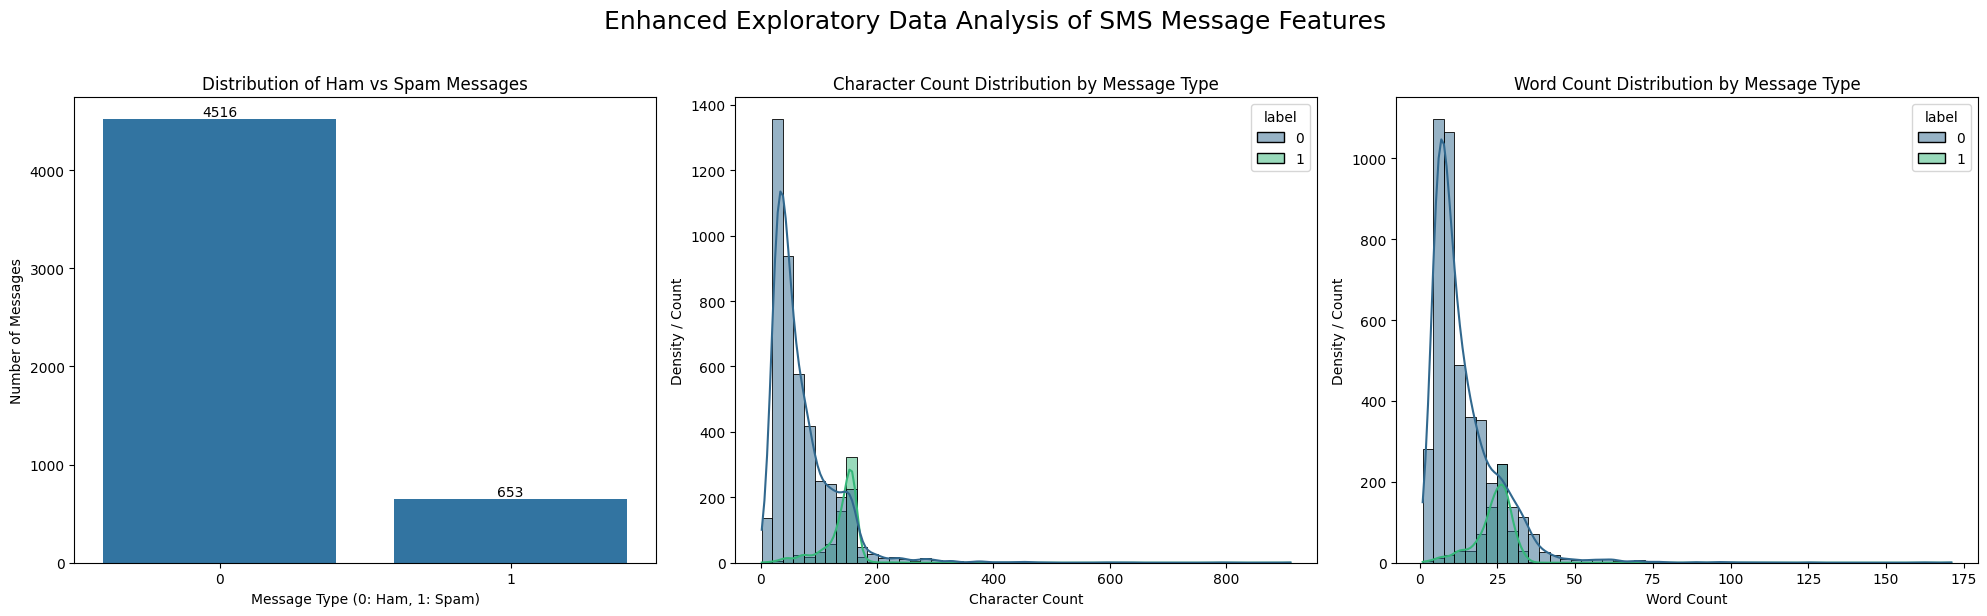

In [25]:
# Ensure necessary NLTK data is available.
# NLTK's download function is idempotent; it won't re-download if already present.
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) # Explicitly download as suggested by the traceback if needed

# Feature Engineering: Calculate message length (character count), word count, and sentence count
df['char_count'] = df['message'].str.len()
df['word_count'] = df['message'].str.split().str.len()
df['sentence_count'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))

# Display descriptive statistics for new features, grouped by message label
print("Descriptive Statistics for Message Features by Label:")
print(df.groupby('label')[['char_count', 'word_count', 'sentence_count']].describe())
print("\n" + "="*80 + "\n") # Separator for readability

# Visualization: Distributions of message length, word count, and label
fig, axes = plt.subplots(1, 3, figsize=(20, 6)) # Create a 1x3 subplot grid, slightly wider for better readability

# Plot 1: Distribution of 'label' (Ham vs Spam)
sns.countplot(data=df, x='label', ax=axes[0])
axes[0].set_title('Distribution of Ham vs Spam Messages')
axes[0].set_xlabel('Message Type (0: Ham, 1: Spam)')
axes[0].set_ylabel('Number of Messages')
# Adding value annotations to countplot
for container in axes[0].containers:
    axes[0].bar_label(container)

# Plot 2: Distribution of 'char_count' by 'label'
sns.histplot(data=df, x='char_count', hue='label', bins=50, kde=True, ax=axes[1], palette='viridis')
axes[1].set_title('Character Count Distribution by Message Type')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Density / Count')

# Plot 3: Distribution of 'word_count' by 'label'
sns.histplot(data=df, x='word_count', hue='label', bins=50, kde=True, ax=axes[2], palette='viridis')
axes[2].set_title('Word Count Distribution by Message Type')
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('Density / Count')

plt.suptitle('Enhanced Exploratory Data Analysis of SMS Message Features', y=1.02, fontsize=18) # Overall title for the figure
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

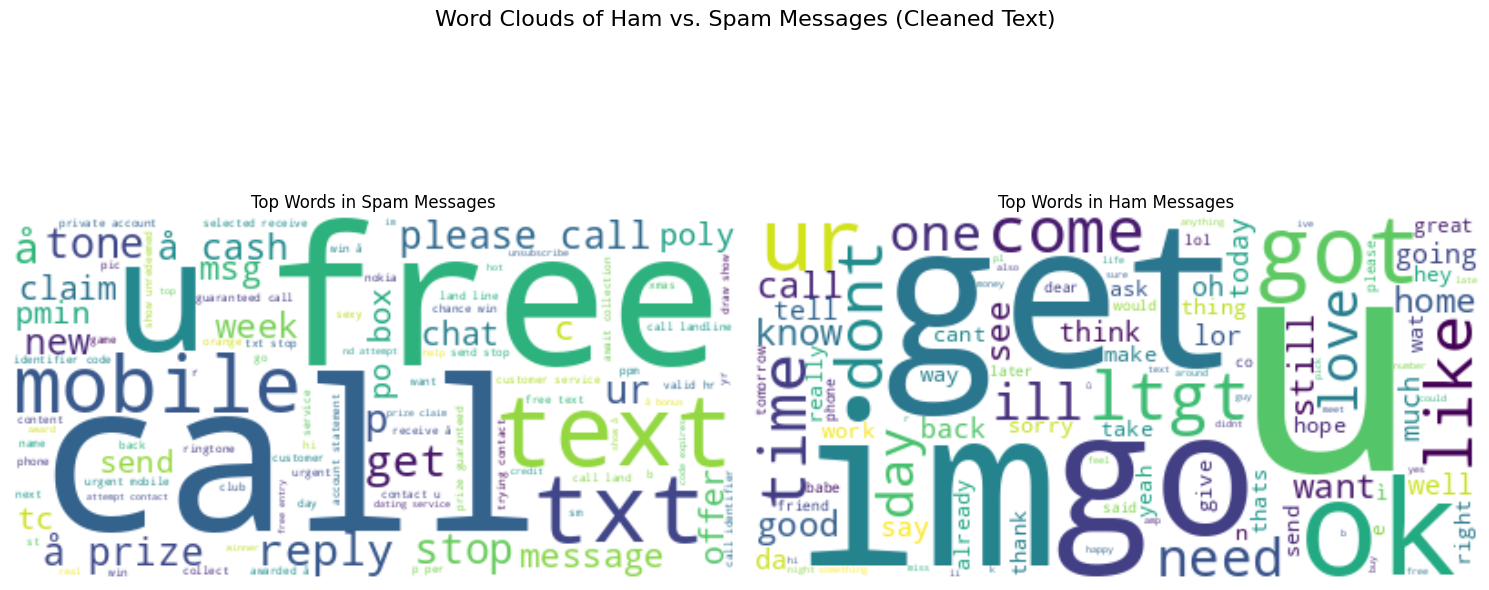

In [26]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords

# Ensure NLTK stopwords are loaded (already done in cc815e32, but good for self-contained code)
# nltk.download('stopwords') # Commented out as it's already downloaded
stop_words = set(stopwords.words('english'))

# Generate a single string of cleaned spam and ham messages
spam_cleaned = ' '.join(df[df.label==1]['clean_message'])
ham_cleaned = ' '.join(df[df.label==0]['clean_message'])

# Create WordCloud objects with enhanced parameters
# max_words helps focus on the most frequent terms
# stopwords parameter further refines by removing common words if they somehow persist
wordcloud_spam = WordCloud(background_color='white', max_words=100, stopwords=stop_words).generate(spam_cleaned)
wordcloud_ham = WordCloud(background_color='white', max_words=100, stopwords=stop_words).generate(ham_cleaned)

# Plotting the word clouds
plt.figure(figsize=(15, 7)) # Increased figure size for better visibility
plt.suptitle('Word Clouds of Ham vs. Spam Messages (Cleaned Text)', fontsize=16, y=1.02) # Added a suptitle

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.axis('off')
plt.title('Top Words in Spam Messages', fontsize=12)

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.axis('off')
plt.title('Top Words in Ham Messages', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

## Preprocessing

In [17]:
# Load the list of English stopwords (e.g., "the", "is", "and")
stop_words = set(stopwords.words('english'))

# Create a WordNet lemmatizer object to convert words to their base form
lemm = WordNetLemmatizer()

# Define a function to clean and preprocess SMS text
def clean_text(text):

    # Convert all characters to lowercase
    text = text.lower()

    # Remove URLs (e.g., http://example.com or www.example.com)
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove email addresses (e.g., abc@gmail.com)
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove all numeric digits from the text
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation marks such as !, ?, ., ,, :, etc.
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Split the sentence into words,
    # remove stopwords,
    # and convert each word to its base (lemma) form
    tokens = [
        lemm.lemmatize(word)
        for word in text.split()
        if word not in stop_words
    ]

    # Join the cleaned words back into a single string
    return ' '.join(tokens)

# Remove duplicate SMS messages from the dataset
df = df.drop_duplicates()

# Apply the clean_text() function to every message
# and store the cleaned text in a new column named 'clean_message'
df['clean_message'] = df['message'].apply(clean_text)

# Convert categorical labels into numerical values
# ham  -> 0
# spam -> 1
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

# Display the first five rows of the processed dataset
df.head()

,label,message,char_count,word_count,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",111,20,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,6,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,free entry wkly comp win fa cup final tkts st ...
3,0,U dun say so early hor... U c already then say...,49,11,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,nah dont think go usf life around though


## Train/Test Split

In [29]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df['clean_message']
y = df['label']

# Split the dataset into training and testing sets
# test_size=0.20 means 20% of data will be used for testing, 80% for training
# random_state ensures reproducibility of the split
# stratify=y ensures that the proportion of classes (spam/ham) in the target variable
# is maintained in both the training and testing sets, which is crucial for imbalanced datasets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Original dataset shape: {X.shape}")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print("\n--- Class Distribution ---")

# Verify class distribution in original, training, and testing sets
original_dist = y.value_counts(normalize=True) * 100
train_dist = y_train.value_counts(normalize=True) * 100
test_dist = y_test.value_counts(normalize=True) * 100

print("Original Data Class Distribution:")
print(original_dist)
print("\nTraining Data Class Distribution:")
print(train_dist)
print("\nTesting Data Class Distribution:")
print(test_dist)

# A more detailed check for stratification effectiveness (optional, but good practice)
if np.allclose(original_dist, train_dist, atol=0.5) and np.allclose(original_dist, test_dist, atol=0.5):
    print("\nClass distribution successfully stratified across train and test sets.")
else:
    print("\nWarning: Class distribution may not be perfectly stratified.")


Original dataset shape: (5169,)
Training set shape: (4135,)
Testing set shape: (1034,)

--- Class Distribution ---
Original Data Class Distribution:
label
0    87.366996
1    12.633004
Name: proportion, dtype: float64

Training Data Class Distribution:
label
0    87.376058
1    12.623942
Name: proportion, dtype: float64

Testing Data Class Distribution:
label
0    87.330754
1    12.669246
Name: proportion, dtype: float64

Class distribution successfully stratified across train and test sets.


## SVM Model

--- Model Performance Metrics ---
Accuracy: 0.9845
Precision: 0.9832
Recall: 0.8931
F1 Score: 0.9360

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.98      0.89      0.94       131

    accuracy                           0.98      1034
   macro avg       0.98      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



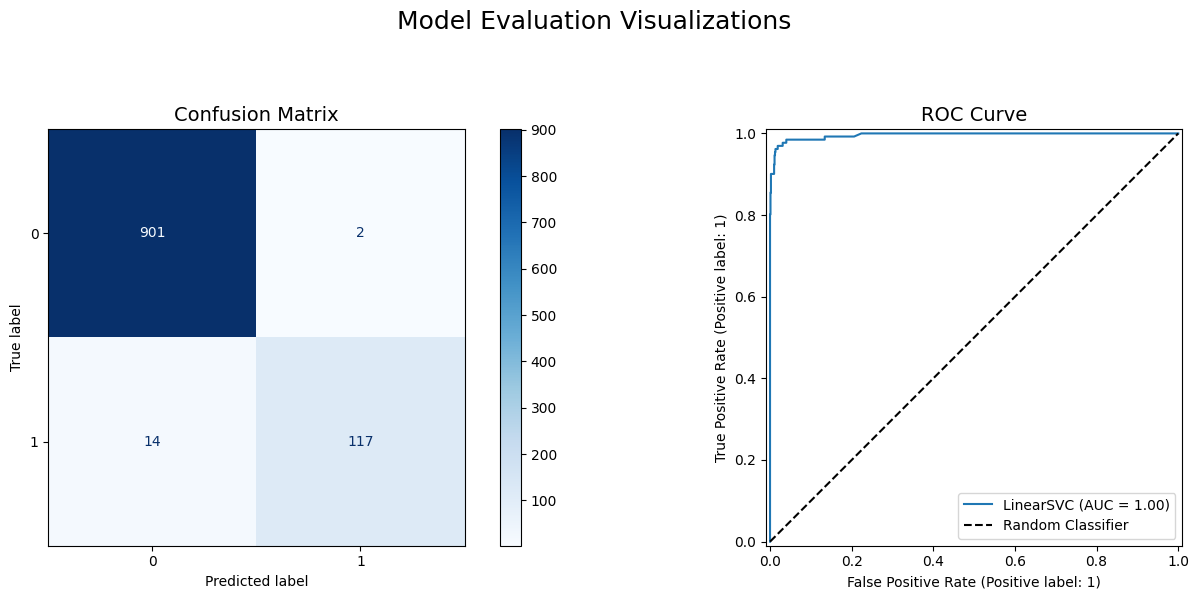

In [30]:
pipeline=Pipeline([
('tfidf',TfidfVectorizer(max_features=5000,ngram_range=(1,2))),
('svm',LinearSVC(random_state=42)) # Added random_state for reproducibility
])

pipeline.fit(X_train,y_train)
pred=pipeline.predict(X_test)

print("--- Model Performance Metrics ---")
print(f"Accuracy: {accuracy_score(y_test,pred):.4f}")
print(f"Precision: {precision_score(y_test,pred):.4f}")
print(f"Recall: {recall_score(y_test,pred):.4f}")
print(f"F1 Score: {f1_score(y_test,pred):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test,pred))

# Visualize Confusion Matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6)) # Create two subplots

# Plot Confusion Matrix
cm_display = ConfusionMatrixDisplay.from_estimator(
    pipeline, X_test, y_test, cmap='Blues', ax=ax1, values_format='d'
)
ax1.set_title('Confusion Matrix', fontsize=14)

# Plot ROC Curve
# LinearSVC does not have predict_proba, but it has decision_function
# We can use decision_function for ROC curve plotting
RocCurveDisplay.from_estimator(
    pipeline, X_test, y_test, name='LinearSVC', ax=ax2
)
ax2.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Add a random classifier baseline
ax2.set_title('ROC Curve', fontsize=14)
ax2.legend()

plt.suptitle('Model Evaluation Visualizations', fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

## Hyperparameter Tuning

In [20]:
param_grid={
'svm__C':[0.1,1,10]
}
grid=GridSearchCV(pipeline,param_grid,cv=5,n_jobs=-1)
grid.fit(X_train,y_train)

print("Best Parameters:",grid.best_params_)
print("Best CV Score:",grid.best_score_)


Best Parameters: {'svm__C': 1}
Best CV Score: 0.9787182587666263


## Cross Validation

In [21]:
scores=cross_val_score(grid.best_estimator_,df['clean_message'],df['label'],cv=5)
print(scores)
print("Mean Accuracy:",scores.mean())


[0.98162476 0.9787234  0.98065764 0.98162476 0.97483059]
Mean Accuracy: 0.9794922302883003


## Prediction Function

In [31]:
model = grid.best_estimator_

# Get the TF-IDF vectorizer and LinearSVC model from the pipeline
tfidf_vectorizer = model.named_steps['tfidf']
svm_classifier = model.named_steps['svm']

# Get feature names (words/ngrams) from the TF-IDF vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Get the coefficients from the SVM classifier (for binary classification, it's a single row)
# These coefficients indicate the importance and direction (spam/ham) of each feature
svm_coefficients = svm_classifier.coef_[0]

# Create a dictionary mapping feature names to their SVM coefficients
feature_importance = dict(zip(feature_names, svm_coefficients))

def predict_sms_enhanced(text):
    """
    Predicts if an SMS message is Spam or Ham, providing confidence and key contributing words.

    Args:
        text (str): The SMS message to classify.

    Returns:
        dict: A dictionary containing the prediction, confidence score, and
              top words contributing to the classification.
    """
    if not isinstance(text, str) or not text.strip():
        return {
            "prediction": "Invalid Input",
            "confidence_score": None,
            "explanation": "Input must be a non-empty string.",
            "top_spam_words": [],
            "top_ham_words": []
        }

    # Clean the input message
    cleaned_text = clean_text(text)
    if not cleaned_text.strip():
        return {
            "prediction": "Undetermined",
            "confidence_score": None,
            "explanation": "Message became empty after cleaning. Cannot classify.",
            "top_spam_words": [],
            "top_ham_words": []
        }

    # Predict the label (0 for Ham, 1 for Spam)
    prediction_label = model.predict([cleaned_text])[0]
    prediction_type = "Spam" if prediction_label == 1 else "Ham"

    # Get the decision function score (a measure of confidence)
    # Higher absolute value means higher confidence.
    # Positive values lean towards the positive class (Spam), negative towards negative (Ham).
    confidence_score = model.decision_function([cleaned_text])[0]

    # Analyze contributing words
    # Transform the cleaned text to TF-IDF features
    text_tfidf = tfidf_vectorizer.transform([cleaned_text])

    # Get the indices of non-zero (present) features in the current message
    present_feature_indices = text_tfidf.nonzero()[1]

    # Get the actual feature names and their importance for the present features
    present_feature_names = [feature_names[i] for i in present_feature_indices]
    present_feature_coefficients = [feature_importance.get(name, 0.0) for name in present_feature_names]

    # Pair features with their coefficients and sort them
    word_contributions = sorted(
        zip(present_feature_names, present_feature_coefficients),
        key=lambda x: x[1],
        reverse=True
    )

    # Extract top spam-contributing and ham-contributing words
    top_spam_words = [(word, round(coeff, 3)) for word, coeff in word_contributions if coeff > 0][:5]
    top_ham_words = [(word, round(coeff, 3)) for word, coeff in word_contributions if coeff < 0][-5:] # Get the 5 most negative (ham)

    return {
        "prediction": prediction_type,
        "confidence_score": float(f"{confidence_score:.4f}"), # Format to 4 decimal places
        "explanation": f"The model predicts this message is {prediction_type} with a confidence score of {confidence_score:.4f}.",
        "top_spam_words": top_spam_words,
        "top_ham_words": top_ham_words
    }

print("--- Enhanced SMS Prediction Function ---")
# Example usage:
spam_message = "Congratulations! You have won a free iPhone. Click here now."
ham_message = "Hi, are we meeting tomorrow at 3 PM?"
neutral_message = "Hello, how are you?" # A more neutral message to test
empty_message = "" # Test empty input

print("\nPrediction for a SPAM-like message:")
print(predict_sms_enhanced(spam_message))

print("\nPrediction for a HAM-like message:")
print(predict_sms_enhanced(ham_message))

print("\nPrediction for a NEUTRAL-like message:")
print(predict_sms_enhanced(neutral_message))

print("\nPrediction for an EMPTY message:")
print(predict_sms_enhanced(empty_message))

--- Enhanced SMS Prediction Function ---

Prediction for a SPAM-like message:
{'prediction': 'Spam', 'confidence_score': 0.0566, 'explanation': 'The model predicts this message is Spam with a confidence score of 0.0566.', 'top_spam_words': [('free', np.float64(1.214)), ('congratulation', np.float64(0.447)), ('click', np.float64(0.321))], 'top_ham_words': []}

Prediction for a HAM-like message:
{'prediction': 'Ham', 'confidence_score': -0.812, 'explanation': 'The model predicts this message is Ham with a confidence score of -0.8120.', 'top_spam_words': [('pm', np.float64(0.675))], 'top_ham_words': [('tomorrow', np.float64(-0.085)), ('hi', np.float64(-0.171)), ('meeting', np.float64(-0.288))]}

Prediction for a NEUTRAL-like message:
{'prediction': 'Ham', 'confidence_score': -0.7053, 'explanation': 'The model predicts this message is Ham with a confidence score of -0.7053.', 'top_spam_words': [('hello', np.float64(0.2))], 'top_ham_words': []}

Prediction for an EMPTY message:
{'prediction

### Interactive SMS Spam Predictor

Use the input box below to test the enhanced spam prediction model with your own SMS messages. The output will include the prediction, confidence score, and the words that most contributed to the classification.

In [33]:
# Interactive Prediction
print("\n--- Interactive SMS Spam Predictor ---")
print("Type an SMS message below and press Enter to get a prediction.")
print("Type 'exit' to stop.\n")

while True:
    user_input = input("Enter SMS message: ")
    if user_input.lower() == 'exit':
        print("Exiting interactive predictor.")
        break

    if user_input.strip() == "":
        print("Please enter a non-empty message.")
        continue

    result = predict_sms_enhanced(user_input)
    print("\nPrediction Result:")
    print(f"  Prediction: {result['prediction']}")
    if result['confidence_score'] is not None:
        print(f"  Confidence Score: {result['confidence_score']:.4f}")
    print(f"  Explanation: {result['explanation']}")
    if result['top_spam_words']:
        print(f"  Top words pushing towards SPAM: {result['top_spam_words']}")
    if result['top_ham_words']:
        print(f"  Top words pushing towards HAM: {result['top_ham_words']}")
    print("\n" + "-"*50 + "\n")


--- Interactive SMS Spam Predictor ---
Type an SMS message below and press Enter to get a prediction.
Type 'exit' to stop.

Enter SMS message: you have 1M dolar

Prediction Result:
  Prediction: Ham
  Confidence Score: -0.9057
  Explanation: The model predicts this message is Ham with a confidence score of -0.9057.

--------------------------------------------------

Enter SMS message: exit
Exiting interactive predictor.
